# Synthetic Extended Runs — Analysis

Compares water-balance response across domain/model setups driven by alternating wet (WY2011) and dry (WY2012) forcing patterns.

**East River setups:** elev × {bigBuckt, noXplict}; elevTPI × {bigBuckt, noXplict}  
**Tuolumne setups:** elev × {noXplict, qTopmodl}; elevTPI × {noXplict, qTopmodl}  
**Patterns:** alt_1w1d … dry10_wet10 (10–20 year runs)

All depth variables (Q, P, ET, SWE) are in mm yr⁻¹ — already area-normalized depth equivalents.  
**Figures are split by basin** (East River left, Tuolumne right) so absolute values are comparable within each panel.  
Dimensionless ratios (runoff ratio, ET/P) share a common y-axis for cross-basin comparison.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

CSV = Path('/scratch/dlhogan/ess-project-data/synthetic_summary.csv')
df  = pd.read_csv(CSV)

# ── Domain ordering: top 2 = East River, bottom 2 = Tuolumne ─────────────────
DOMAIN_ORDER = [
    'East_River_distributed',
    'East_River_distributed_elevTPI',
    'Tuolumne_River_distributed_elev',
    'Tuolumne_River_distributed_elevTPI',
]
DOMAIN_LABELS = {
    'East_River_distributed'            : 'ER · Elev',
    'East_River_distributed_elevTPI'    : 'ER · Elev+TPI',
    'Tuolumne_River_distributed_elev'   : 'Tu · Elev',
    'Tuolumne_River_distributed_elevTPI': 'Tu · Elev+TPI',
}

MODEL_ORDER   = ['bigBuckt', 'noXplict', 'qTopmodl']
MODEL_COLORS  = {'bigBuckt': '#4878CF', 'noXplict': '#D65F5F', 'qTopmodl': '#6ACC65'}
MODEL_MARKERS = {'bigBuckt': 'o',       'noXplict': 's',       'qTopmodl': '^'}

ALT_PATTERNS = ['alt_1w1d', 'alt_2w2d', 'alt_3w3d', 'alt_4w4d', 'alt_5w5d_wf', 'alt_5w5d_df']
ALT_LABELS   = {
    'alt_1w1d'    : '1W·1D',
    'alt_2w2d'    : '2W·2D',
    'alt_3w3d'    : '3W·3D',
    'alt_4w4d'    : '4W·4D',
    'alt_5w5d_wf' : '5W·5D',
    'alt_5w5d_df' : '5W·5D',
}
BLOCK_PATTERNS = ['wet10_dry10', 'dry10_wet10']
BLOCK_LABELS   = {
    'wet10_dry10': '10 Wet → 10 Dry',
    'dry10_wet10': '10 Dry → 10 Wet',
}

WET_COLOR = '#2166ac'
DRY_COLOR = '#b2182b'

# Storage: july SWE + soil moisture + aquifer (bigBuckt only, m → mm)
# min_aquifer_mm column stores values in metres despite the name
df['aquifer_mm']      = np.where(df['model'] == 'bigBuckt', df['min_aquifer_mm'] * 1000, 0.0)
df['total_storage_mm'] = df['july_swe_mm'] + df['mean_soil_liq_mm'] + df['aquifer_mm']

print(f"Rows: {len(df)}")
print("Domains:", df['domain'].unique().tolist())
print("Patterns:", df['pattern'].unique().tolist())
df.head(3)

Rows: 816
Domains: ['East_River_distributed', 'East_River_distributed_elevTPI', 'Tuolumne_River_distributed_elev', 'Tuolumne_River_distributed_elevTPI']
Patterns: ['alt_1w1d', 'alt_2w2d', 'alt_3w3d', 'alt_4w4d', 'alt_5w5d_wf', 'alt_5w5d_df', 'wet10_dry10', 'dry10_wet10']


,domain,model,pattern,water_year,year_idx,year_type,total_q_mm,total_p_mm,runoff_ratio,total_et_mm,peak_swe_mm,peak_swe_dowy,july_swe_mm,days_with_snow,mean_soil_liq_mm,min_aquifer_mm,peak_q_dowy,com_q_dowy,aquifer_mm,total_storage_mm
0,East_River_distributed,bigBuckt,alt_1w1d,2021,0,W,540.13,1012.72,0.5333,373.60,551.76,215.0,2.79,261,159.09,0.0825,243.0,255.8,82.5,244.38
1,East_River_distributed,bigBuckt,alt_1w1d,2022,1,D,160.48,583.05,0.2752,415.15,192.52,155.0,0.00,218,154.91,0.0939,179.0,182.0,93.9,248.81
2,East_River_distributed,bigBuckt,alt_1w1d,2023,2,W,516.23,1012.72,0.5097,374.35,551.65,215.0,2.79,266,159.44,0.0763,243.0,262.1,76.3,238.53


## Transition-Year Water Balance Timeseries

Daily timeseries for the **final transition water year** of each model × pattern combination:
- **Block patterns** (`wet10_dry10`, `dry10_wet10`): WY2031 — the first year after the 10-year drought or deluge
- **Alternating patterns** (`alt_*`): WY2040 — the final year of the run

Rows: streamflow · SWE · subsurface storage (soil + aquifer) · ET+sublimation  
Colors: groundwater parameterization · Line style: domain discretization (solid=Elev, dashed=ElevTPI)  
Block patterns are drawn opaque; alternating patterns are drawn as faint background spaghetti.

In [2]:
import warnings
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path

warnings.filterwarnings('ignore')

BASE  = Path('/scratch/dlhogan/ess-project-data')
SYNTH = 'synthetic_extended_runs'

DOMAIN_MODEL = {
    'East_River_distributed_elevAspect':     'bigBuckt',
    'Tuolumne_River_distributed_elevTPI': 'qTopmodl',
}
DOMAIN_LABELS_FIG = {
    'East_River_distributed_elevAspect':     'East River · Elev+Aspect  (bigBuckt)',
    'Tuolumne_River_distributed_elevTPI': 'Tuolumne · Elev+TPI  (qTopmodl)',
}

# Each pattern has a different run length (years):
#   alt_1w1d=10, alt_2w2d=12, alt_3w3d=12, alt_4w4d=8, alt_5w5d_*=10, blocks=20
PATTERN_N_YEARS = {
    'alt_1w1d'   : 11, 'alt_2w2d'   : 11, 'alt_3w3d'   : 10,
    'alt_4w4d'   :  9, 'alt_5w5d_wf': 11, 'alt_5w5d_df': 11,
    'wet10_dry10': 11, 'dry10_wet10': 11,
}
FIRST_WY = 2021  # WY2021 starts Oct 2020

def get_win(pattern):
    """3-year window ending at the last (or transition) WY of each pattern."""
    n = PATTERN_N_YEARS[pattern]
    if pattern in BLOCK_PATTERNS:
        last_wy = FIRST_WY + 10   # year-11 = WY2031, first year after 10-yr block
    else:
        last_wy = FIRST_WY + n - 1
    t1 = f'{last_wy}-09-30'
    t0 = f'{last_wy - 3}-10-01'
    return t0, t1

YR_BOUNDS = [1, 366, 731]

# Pre-load basin areas and HRU weights
basin_area  = {}
hru_weights = {}
for domain in DOMAIN_MODEL:
    with xr.open_dataset(
            BASE / f'domain_{domain}' / 'settings' / 'SUMMA' / 'attributes.nc') as dsa:
        a = dsa['HRUarea'].values.ravel().astype(float)
        basin_area[domain]  = float(a.sum())
        hru_weights[domain] = a / a.sum()

def _area_mean(da, w):
    arr = da.values
    if arr.ndim == 2:
        return (arr * w[None, :arr.shape[1]]).sum(axis=1)
    return arr.ravel()

def load_3yr(domain, model, pattern):
    t0, t1 = get_win(pattern)
    nc = (BASE / f'domain_{domain}' / 'simulations' / SYNTH /
          model / pattern / 'output' /
          f'synthetic_{domain}_{model}_{pattern}_timestep.nc')
    if not nc.exists():
        print(f'  MISSING: {nc.name}')
        return None

    w    = hru_weights[domain]
    area = basin_area[domain]
    ref  = pd.Timestamp(t0)

    ds  = xr.open_dataset(nc).sel(time=slice(t0, t1))
    ti  = pd.DatetimeIndex(ds.time.values)
    if len(ti) == 0:
        print(f'  EMPTY SLICE: {domain}/{model}/{pattern}  window={t0}:{t1}')
        ds.close(); return None

    # ── Streamflow (m³/s daily mean)
    q_d = (pd.Series(ds['averageRoutedRunoff'].mean(dim='gru').values.ravel() * area, index=ti)
             .resample('1D').mean())

    # ── SWE (kg/m² = mm, area-weighted daily mean)
    swe_arr = _area_mean(ds['scalarSWE'], w)
    swe_d   = pd.Series(swe_arr, index=ti).resample('1D').mean()

    # ── Total storage in numpy space (avoids pandas alignment issues)
    #    SWE + soil liq + soil ice + aquifer (all in mm)
    soil_arr = _area_mean(ds['scalarTotalSoilLiq'], w).copy()
    if 'scalarTotalSoilIce' in ds:
        soil_arr += _area_mean(ds['scalarTotalSoilIce'], w)
    aq_arr = np.zeros(len(swe_arr))
    if 'scalarAquiferStorage_mean' in ds:
        aq_arr = _area_mean(ds['scalarAquiferStorage_mean'], w) * 1000  # m -> mm
    total_arr = swe_arr + soil_arr + aq_arr
    total_d   = pd.Series(total_arr, index=ti).resample('1D').mean()
    cum_stor  = total_d - float(total_d.iloc[0])

    # ── ET + sublimation (monthly mm)
    et_arr = _area_mean(ds['scalarTotalET'], w).copy()
    for v in ('scalarCanopySublimation', 'scalarSnowSublimation'):
        if v in ds:
            et_arr += _area_mean(ds[v], w)
    et_daily   = pd.Series(np.abs(et_arr) * 3600, index=ti).resample('1D').sum()
    et_monthly = et_daily.resample('MS').sum()
    et_m_rel   = ((et_monthly.index + pd.Timedelta(days=15) - ref).days + 1).values

    ds.close()
    rel = (q_d.index - ref).days + 1
    return {
        'q':        pd.Series(q_d.values,        index=rel),
        'swe':      pd.Series(swe_d.values,      index=rel),
        'cum_stor': pd.Series(cum_stor.values,   index=rel),
        'et_m':     pd.Series(et_monthly.values, index=et_m_rel),
    }

print("Loading 3-year windows...", flush=True)
all_data = {}
for domain, model in DOMAIN_MODEL.items():
    for pattern in BLOCK_PATTERNS + ALT_PATTERNS:
        t0, t1 = get_win(pattern)
        d = load_3yr(domain, model, pattern)
        if d is not None:
            all_data[(domain, model, pattern)] = d
        print(f'  {domain[:20]} / {model} / {pattern} [{t0}:{t1}]: {"OK" if d is not None else "SKIP"}')

print(f"\nLoaded {len(all_data)} / {len(DOMAIN_MODEL) * len(BLOCK_PATTERNS + ALT_PATTERNS)} combinations.")


Loading 3-year windows...
  East_River_distribut / bigBuckt / wet10_dry10 [2028-10-01:2031-09-30]: OK
  East_River_distribut / bigBuckt / dry10_wet10 [2028-10-01:2031-09-30]: OK
  East_River_distribut / bigBuckt / alt_1w1d [2028-10-01:2031-09-30]: OK
  East_River_distribut / bigBuckt / alt_2w2d [2028-10-01:2031-09-30]: OK
  East_River_distribut / bigBuckt / alt_3w3d [2027-10-01:2030-09-30]: OK
  East_River_distribut / bigBuckt / alt_4w4d [2026-10-01:2029-09-30]: OK
  East_River_distribut / bigBuckt / alt_5w5d_wf [2028-10-01:2031-09-30]: OK
  East_River_distribut / bigBuckt / alt_5w5d_df [2028-10-01:2031-09-30]: OK
  Tuolumne_River_distr / qTopmodl / wet10_dry10 [2028-10-01:2031-09-30]: OK
  Tuolumne_River_distr / qTopmodl / dry10_wet10 [2028-10-01:2031-09-30]: OK
  Tuolumne_River_distr / qTopmodl / alt_1w1d [2028-10-01:2031-09-30]: OK
  Tuolumne_River_distr / qTopmodl / alt_2w2d [2028-10-01:2031-09-30]: OK
  Tuolumne_River_distr / qTopmodl / alt_3w3d [2027-10-01:2030-09-30]: OK
  Tuolu

Loading final-year data...
  alt_1w1d WY2030 (D): aug_swe=87 mm  soil=234 mm
  alt_2w2d WY2030 (W): aug_swe=346 mm  soil=297 mm
  alt_3w3d WY2030 (D): aug_swe=223 mm  soil=218 mm
  alt_5w5d_wf WY2030 (D): aug_swe=113 mm  soil=208 mm
  alt_5w5d_df WY2030 (W): aug_swe=679 mm  soil=292 mm
  wet10_dry10 WY2031 (D): aug_swe=1295 mm  soil=194 mm
  dry10_wet10 WY2031 (W): aug_swe=126 mm  soil=315 mm


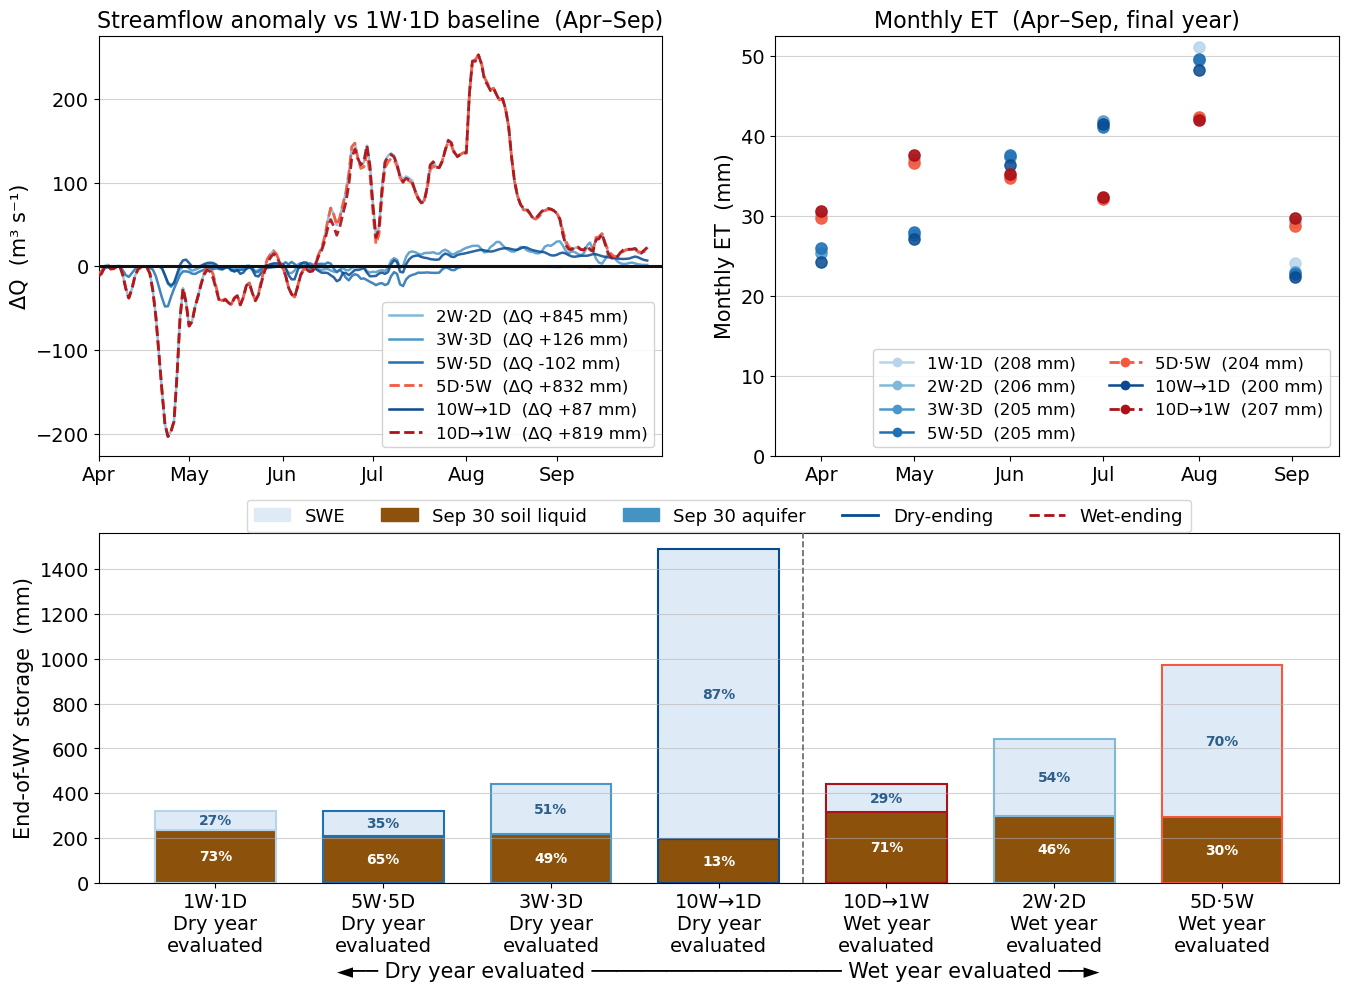

Saved → ess-project/figures/synthetic_fig_ensemble_style.png


In [8]:
# Spring-Ensemble-style figure for synthetic runs
# Top-left : Q anomaly vs alt_1w1d baseline  (Apr–Sep, final year)
# Top-right: Monthly ET scatter              (Apr–Sep, final year)
# Bottom   : Stacked storage bars — dry-evaluated left, wet-evaluated right

import sys, warnings
import xarray as xr, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches, matplotlib.lines as mlines
import matplotlib.cm as cm
from pathlib import Path

warnings.filterwarnings('ignore')

BASE  = Path('/scratch/dlhogan/ess-project-data')
SYNTH = 'synthetic_extended_runs'

FOCUS_DOMAIN = 'Tuolumne_River_distributed_elevTPI'
FOCUS_MODEL  = 'qTopmodl'

DRY_END   = ['alt_1w1d', 'alt_2w2d', 'alt_3w3d', 'alt_5w5d_wf', 'wet10_dry10']
WET_END   = ['alt_5w5d_df', 'dry10_wet10']

BAR_ORDER = ['alt_1w1d', 'alt_2w2d', 'alt_3w3d',
             'alt_5w5d_wf', 'alt_5w5d_df',
             'wet10_dry10', 'dry10_wet10']

# last fully-simulated water year per pattern
FINAL_WY = {
    'alt_1w1d':    2030, 'alt_2w2d':    2030, 'alt_3w3d':    2030,
    'alt_5w5d_wf': 2030, 'alt_5w5d_df': 2030,
    'wet10_dry10': 2031, 'dry10_wet10': 2031,
}
LABELS = {
    'alt_1w1d': '1W·1D', 'alt_2w2d': '2W·2D', 'alt_3w3d': '3W·3D',
    'alt_5w5d_wf': '5W·5D', 'alt_5w5d_df': '5D·5W',
    'wet10_dry10': '10W→1D', 'dry10_wet10': '10D→1W',
}

DRY_CMAP = dict(zip(DRY_END, cm.Blues(np.linspace(0.30, 0.90, len(DRY_END)))))
WET_CMAP = dict(zip(WET_END, cm.Reds( np.linspace(0.55, 0.85, len(WET_END)))))
BLUE_REP = DRY_CMAP[DRY_END[-1]]
RED_REP  = WET_CMAP[WET_END[-1]]

def _style(pat):
    if pat in WET_END: return WET_CMAP[pat], 2.0, '--', 4, 0.92
    return DRY_CMAP[pat], 1.8, '-', 3, 0.85

# ── HRU weights ───────────────────────────────────────────────────────────
with xr.open_dataset(BASE / f'domain_{FOCUS_DOMAIN}/settings/SUMMA/attributes.nc') as _ds:
    _a = _ds['HRUarea'].values.ravel().astype(float)
    BASIN_AREA = float(_a.sum())
    HRU_W = _a / _a.sum()

def _am(da):
    arr = da.values
    return (arr * HRU_W[None, :arr.shape[1]]).sum(axis=1) if arr.ndim == 2 else arr.ravel()

_csv = pd.read_csv(BASE / 'synthetic_summary.csv')
_csv = _csv[(_csv['domain'] == FOCUS_DOMAIN) & (_csv['model'] == FOCUS_MODEL)]

APR_DOY = 183
SEP_DOY = 365

def load_final_year(pat):
    wy  = FINAL_WY[pat]
    nc  = (BASE / f'domain_{FOCUS_DOMAIN}/simulations/{SYNTH}'
           f'/{FOCUS_MODEL}/{pat}/output'
           f'/synthetic_{FOCUS_DOMAIN}_{FOCUS_MODEL}_{pat}_timestep.nc')
    if not nc.exists(): return None
    with xr.open_dataset(nc) as ds:
        ds  = ds.sel(time=slice(f'{wy-1}-10-01', f'{wy}-09-30'))
        ti  = pd.DatetimeIndex(ds.time.values)
        if len(ti) == 0: return None
        ref = pd.Timestamp(f'{wy-1}-10-01')

        q_d = (pd.Series(ds['averageRoutedRunoff'].mean(dim='gru').values.ravel() * BASIN_AREA, index=ti)
               .resample('1D').mean())

        et_arr = _am(ds['scalarTotalET']).copy()
        for v in ('scalarCanopySublimation', 'scalarSnowSublimation'):
            if v in ds: et_arr += _am(ds[v])
        et_d = pd.Series(np.abs(et_arr) * 3600, index=ti).resample('1D').sum()
        et_monthly = et_d[et_d.index >= pd.Timestamp(f'{wy}-04-01')].resample('MS').sum()
        et_mo = pd.Series(et_monthly.values,
                          index=(et_monthly.index - ref).days + 1 + 15)

        soil = float(pd.Series(_am(ds['scalarTotalSoilLiq']), index=ti)
                     .resample('1D').mean().iloc[-1])

        aq_key = next((v for v in ['scalarAquiferStorage_mean', 'scalarAquiferStorage'] if v in ds), None)
        aq = (float(pd.Series(_am(ds[aq_key]) * 1000, index=ti).resample('1D').mean().iloc[-1])
              if aq_key and FOCUS_MODEL == 'bigBuckt' else 0.0)

        swe_daily = pd.Series(_am(ds['scalarSWE']), index=ti).resample('1D').mean()
        aug_swe   = float(swe_daily.get(pd.Timestamp(f'{wy}-09-30'), 0.0))

    row = _csv[(_csv['pattern'] == pat) & (_csv['water_year'] == wy)]
    year_type = str(row['year_type'].iloc[0]) if len(row) else '?'

    doy = (q_d.index - ref).days + 1
    return {'q': pd.Series(q_d.values, index=doy), 'et_mo': et_mo,
            'soil': soil, 'aq': aq, 'aug_swe': aug_swe, 'year_type': year_type}

print('Loading final-year data...')
DATA = {}
for p in BAR_ORDER:
    d = load_final_year(p)
    DATA[p] = d
    if d:
        print(f'  {p} WY{FINAL_WY[p]} ({d["year_type"]}): aug_swe={d["aug_swe"]:.0f} mm  soil={d["soil"]:.0f} mm')
    else:
        print(f'  {p}: MISSING or empty slice')

REF_PAT = 'alt_1w1d'
ref_q   = DATA[REF_PAT]['q'].reindex(range(APR_DOY, SEP_DOY + 1))

# bars: dry-evaluated first (sorted by SWE), then wet-evaluated (sorted by SWE)
valid = [p for p in BAR_ORDER if DATA.get(p)]
stor_order = (
    sorted([p for p in valid if DATA[p]['year_type'] == 'D'], key=lambda p: DATA[p]['aug_swe']) +
    sorted([p for p in valid if DATA[p]['year_type'] == 'W'], key=lambda p: DATA[p]['aug_swe'])
)

# ── Styling ───────────────────────────────────────────────────────────────
BLACK    = '#111111'
COL_AQ   = '#4393c3'
COL_SOIL = '#8c510a'
COL_SWE  = '#deebf7'
GRD      = dict(axis='y', lw=0.8, alpha=0.55)
FS       = dict(ti=16, ax=15, tk=14, lg=13, an=14)
PCT_MIN  = 5.0
_APR_TICKS  = [183, 213, 244, 274, 305, 335]
_APR_LABELS = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']

# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1.2, 1.0])
ax_q  = fig.add_subplot(gs[0, 0])
ax_et = fig.add_subplot(gs[0, 1])
ax_st = fig.add_subplot(gs[1, :])

# ── Q anomaly — plot lines, build legend with cumulative ΔQ ──────────────
q_handles = []
for p in BAR_ORDER:
    d = DATA.get(p)
    if p == REF_PAT:
        continue
    if not d: continue
    c, lw, ls, zo, al = _style(p)
    q_s  = d['q'].reindex(range(APR_DOY, SEP_DOY + 1))
    anom = q_s - ref_q
    ax_q.plot(anom.index, anom.values, color=c, lw=lw, ls=ls, alpha=al, zorder=zo)
    cum_dq_mm = float(anom.dropna().sum() * 86400 / BASIN_AREA * 1000)
    lbl = f'{LABELS[p]}  (reference)' if p == REF_PAT else f'{LABELS[p]}  (ΔQ {cum_dq_mm:+.0f} mm)'
    q_handles.append(mlines.Line2D([], [], color=c, lw=lw, ls=ls, label=lbl))

ax_q.axhline(0, color=BLACK, lw=2.2, zorder=6, label='Reference (1W·1D)')
ax_q.axhline(0, color='0.5', lw=0.8, ls=':', zorder=1)
ax_q.set_xticks(_APR_TICKS); ax_q.set_xticklabels(_APR_LABELS, fontsize=FS['tk'])
ax_q.set_xlim(APR_DOY, SEP_DOY + 5)
ax_q.set_ylabel('ΔQ  (m³ s⁻¹)', fontsize=FS['ax'])
ax_q.set_title('Streamflow anomaly vs 1W·1D baseline  (Apr–Sep)', fontsize=FS['ti'])
ax_q.grid(True, **GRD); ax_q.tick_params(axis='y', labelsize=FS['tk'])
ax_q.legend(handles=q_handles, fontsize=FS['lg'] - 1, loc='lower right',
            frameon=True, framealpha=0.85, ncol=1)

# ── Monthly ET scatter (Apr–Sep) ──────────────────────────────────────────
et_handles = []
et_totals  = {}
for p in BAR_ORDER:
    d = DATA.get(p)
    if not d: continue
    c, lw, ls, zo, al = _style(p)
    ax_et.scatter(d['et_mo'].index, d['et_mo'].values, color=c, s=65, alpha=al, zorder=zo)
    total_et = float(d['et_mo'].sum())
    et_totals[p] = total_et
    et_handles.append(mlines.Line2D([], [], color=c, lw=lw, ls=ls, marker='o', ms=6,
                                    label=f'{LABELS[p]}  ({total_et:.0f} mm)'))

ax_et.set_xticks([t + 15 for t in _APR_TICKS]); ax_et.set_xticklabels(_APR_LABELS, fontsize=FS['tk'])
ax_et.set_xlim(APR_DOY, SEP_DOY); ax_et.set_ylim(bottom=0)
ax_et.set_ylabel('Monthly ET  (mm)', fontsize=FS['ax'])
ax_et.set_title('Monthly ET  (Apr–Sep, final year)', fontsize=FS['ti'])
ax_et.grid(True, **GRD); ax_et.tick_params(axis='y', labelsize=FS['tk'])
ax_et.legend(handles=et_handles, fontsize=FS['lg'] - 1, loc='lower right',
             frameon=True, framealpha=0.85, ncol=2)

# ── Stacked storage bars: dry-evaluated left, wet-evaluated right ─────────
n = len(stor_order); x = np.arange(n); BAR_W = 0.72
aq   = np.array([DATA[p]['aq']      for p in stor_order])
soil = np.array([DATA[p]['soil']    for p in stor_order])
swe  = np.array([DATA[p]['aug_swe'] for p in stor_order])
total_safe = np.where(aq + soil + swe == 0, 1.0, aq + soil + swe)
aq_pct   = aq   / total_safe * 100
soil_pct = soil / total_safe * 100
swe_pct  = swe  / total_safe * 100

n_dry = sum(1 for p in stor_order if DATA[p]['year_type'] == 'D')

for i, p in enumerate(stor_order):
    ec = WET_CMAP.get(p, DRY_CMAP.get(p, '0.55'))
    ax_st.bar(x[i], aq[i],   BAR_W, color=COL_AQ,   edgecolor=ec, lw=1.5)
    ax_st.bar(x[i], soil[i], BAR_W, color=COL_SOIL, edgecolor=ec, lw=1.5, bottom=aq[i])
    ax_st.bar(x[i], swe[i],  BAR_W, color=COL_SWE,  edgecolor=ec, lw=1.5, bottom=aq[i]+soil[i])
    txt = dict(ha='center', va='center', fontsize=10, fontweight='bold', clip_on=True)
    if aq_pct[i]   >= PCT_MIN: ax_st.text(x[i], aq[i]/2,                 f'{aq_pct[i]:.0f}%',   color='white',   **txt)
    if soil_pct[i] >= PCT_MIN: ax_st.text(x[i], aq[i]+soil[i]/2,         f'{soil_pct[i]:.0f}%', color='white',   **txt)
    if swe_pct[i]  >= PCT_MIN: ax_st.text(x[i], aq[i]+soil[i]+swe[i]/2, f'{swe_pct[i]:.0f}%',  color='#2c5f8a', **txt)

# divider between dry and wet groups
if 0 < n_dry < n:
    ax_st.axvline(n_dry - 0.5, color='0.4', lw=1.2, ls='--', zorder=5)

xtick_labels = [
    f'{LABELS[p]}\n{"Dry" if DATA[p]["year_type"] == "D" else "Wet"} year\nevaluated'
    for p in stor_order
]
ax_st.set_xticks(x); ax_st.set_xticklabels(xtick_labels, fontsize=FS['tk'])
ax_st.set_ylabel('End-of-WY storage  (mm)', fontsize=FS['ax'])
ax_st.set_xlabel(
    '◄── Dry year evaluated ──────────────────── Wet year evaluated ──►',
    fontsize=FS['ax']
)
ax_st.grid(True, **GRD); ax_st.tick_params(axis='y', labelsize=FS['tk'])
ax_st.legend(handles=[
    mpatches.Patch(color=COL_SWE,  label='SWE'),
    mpatches.Patch(color=COL_SOIL, label='Sep 30 soil liquid'),
    mpatches.Patch(color=COL_AQ,   label='Sep 30 aquifer'),
    mlines.Line2D([], [], color=BLUE_REP, lw=2,          label='Dry-ending'),
    mlines.Line2D([], [], color=RED_REP,  lw=2, ls='--', label='Wet-ending'),
], fontsize=FS['lg'], loc='upper center', frameon=True,
   ncol=5, bbox_to_anchor=(0.5, 1.12))

out = Path('ess-project/figures/synthetic_fig_ensemble_style.png')
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')
